In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
usa_tables = Path("../reports/usa/tables")

budget = pd.read_csv(
    usa_tables / "usa_budget_impact_summary.csv"
)

budget

,Measure,Value
0,Adult population (18+),2.697635e+08
1,Obesity prevalence,3.306260e+01
2,Adults with obesity,8.919083e+07
3,Annual drug cost per patient,1.753726e+04
4,Treatment uptake Year 1,5.000000e-02
5,Treatment uptake Year 5,2.500000e-01
6,Treated population Year 1,4.459542e+06
7,Treated population Year 5,2.229771e+07
8,Gross drug cost Year 1,7.820814e+10
9,Gross drug cost Year 5,3.910407e+11


In [16]:
budget.columns

Index(['Measure', 'Value'], dtype='str')

In [18]:
import matplotlib.pyplot as plt

treated_population = pd.DataFrame({
    "Year": ["Year 1", "Year 5"],
    "Population": [
        budget.loc[
            budget["Measure"]=="Treated population Year 1",
            "Value"
        ].values[0],
        budget.loc[
            budget["Measure"]=="Treated population Year 5",
            "Value"
        ].values[0]
    ]
})

treated_population

,Year,Population
0,Year 1,4.459542e+06
1,Year 5,2.229771e+07


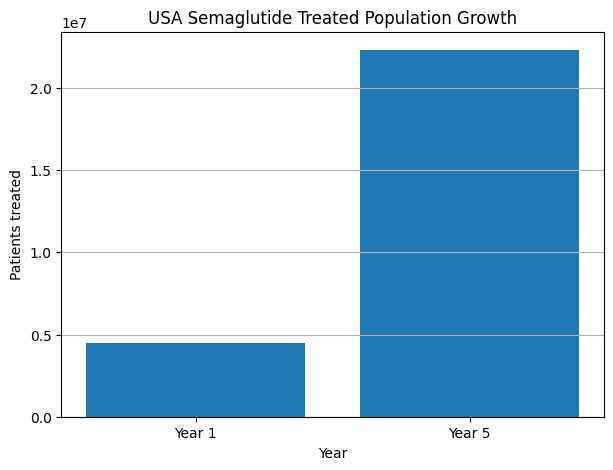

In [19]:
plt.figure(figsize=(7,5))

plt.bar(
    treated_population["Year"],
    treated_population["Population"]
)

plt.xlabel("Year")
plt.ylabel("Patients treated")

plt.title(
    "USA Semaglutide Treated Population Growth"
)

plt.grid(axis="y")

plt.savefig(
    "../reports/usa/figures/usa_treated_population.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
budget_impact = pd.DataFrame({
    "Year": ["Year 1", "Year 5"],
    "Cost": [
        budget.loc[
            budget["Measure"]=="Net budget impact Year 1",
            "Value"
        ].values[0],
        budget.loc[
            budget["Measure"]=="Net budget impact Year 5",
            "Value"
        ].values[0]
    ]
})

budget_impact

,Year,Cost
0,Year 1,6.746956e+10
1,Year 5,3.373478e+11


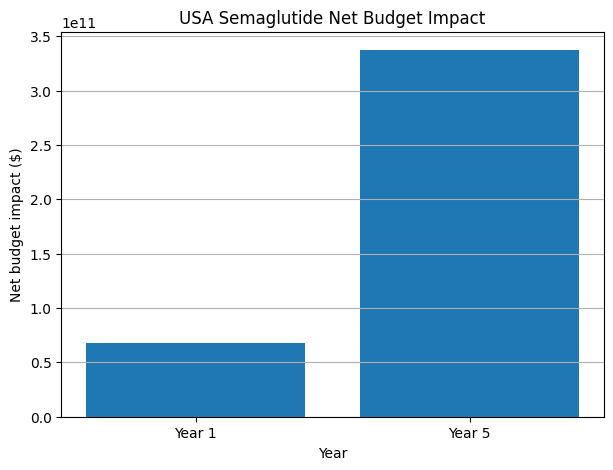

In [21]:
plt.figure(figsize=(7,5))

plt.bar(
    budget_impact["Year"],
    budget_impact["Cost"]
)

plt.xlabel("Year")
plt.ylabel("Net budget impact ($)")

plt.title(
    "USA Semaglutide Net Budget Impact"
)

plt.grid(axis="y")

plt.savefig(
    "../reports/usa/figures/usa_net_budget_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
from pathlib import Path
import pandas as pd

comparison_file = Path("../reports/comparison/uk_vs_usa_summary.csv")

comparison = pd.read_csv(comparison_file)

comparison

,Metric,United Kingdom,United States
0,Adult population,55.0 million,269.8 million
1,Obesity prevalence,29.9%,33.1%
2,Eligible population,3.29 million,89.2 million
3,Annual treatment cost,"£2,500","$17,537"
4,Year 1 budget impact,£394.9 million,$67.5 billion
5,Year 5 budget impact,£1.97 billion,$337.3 billion


In [23]:
comparison.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Metric          6 non-null      str  
 1   United Kingdom  6 non-null      str  
 2   United States   6 non-null      str  
dtypes: str(3)
memory usage: 276.0 bytes


In [24]:
comparison.columns

Index(['Metric', 'United Kingdom', 'United States'], dtype='str')

In [25]:
comparison

,Metric,United Kingdom,United States
0,Adult population,55.0 million,269.8 million
1,Obesity prevalence,29.9%,33.1%
2,Eligible population,3.29 million,89.2 million
3,Annual treatment cost,"£2,500","$17,537"
4,Year 1 budget impact,£394.9 million,$67.5 billion
5,Year 5 budget impact,£1.97 billion,$337.3 billion


In [26]:
from pathlib import Path

usa_figures = Path("../reports/usa/figures")

usa_figures.mkdir(parents=True, exist_ok=True)

print("USA figures folder:")
print(usa_figures)

print("Exists:", usa_figures.exists())

USA figures folder:
..\reports\usa\figures
Exists: True


In [28]:
import pandas as pd

usa_budget = pd.DataFrame({
    "Year": [1,2,3,4,5],
    "Treated Population": [
        4459542,
        8919084,
        13378626,
        17838268,
        22297710
    ],
    "Gross Drug Cost": [
        78208140000,
        156416280000,
        234624420000,
        312832560000,
        391040700000
    ],
    "Healthcare Savings": [
        10738580000,
        21477160000,
        32215740000,
        42954320000,
        53692880000
    ],
    "Net Budget Impact": [
        67469560000,
        134939120000,
        202408680000,
        269878240000,
        337347819543
    ]
})


usa_budget

,Year,Treated Population,Gross Drug Cost,Healthcare Savings,Net Budget Impact
0,1,4459542,78208140000,10738580000,67469560000
1,2,8919084,156416280000,21477160000,134939120000
2,3,13378626,234624420000,32215740000,202408680000
3,4,17838268,312832560000,42954320000,269878240000
4,5,22297710,391040700000,53692880000,337347819543


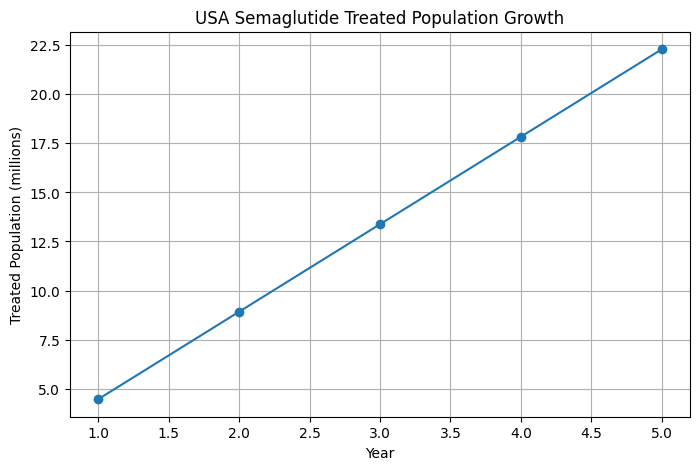

In [29]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(
    usa_budget["Year"],
    usa_budget["Treated Population"]/1_000_000,
    marker="o"
)

plt.title("USA Semaglutide Treated Population Growth")
plt.xlabel("Year")
plt.ylabel("Treated Population (millions)")

plt.grid(True)

plt.savefig(
    usa_figures / "usa_treated_population_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

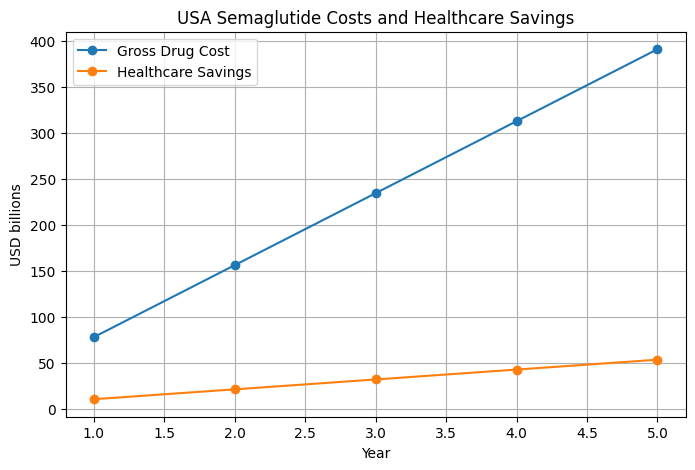

In [30]:
plt.figure(figsize=(8,5))


plt.plot(
    usa_budget["Year"],
    usa_budget["Gross Drug Cost"]/1_000_000_000,
    marker="o",
    label="Gross Drug Cost"
)


plt.plot(
    usa_budget["Year"],
    usa_budget["Healthcare Savings"]/1_000_000_000,
    marker="o",
    label="Healthcare Savings"
)


plt.title(
    "USA Semaglutide Costs and Healthcare Savings"
)

plt.xlabel("Year")

plt.ylabel(
    "USD billions"
)

plt.legend()

plt.grid(True)


plt.savefig(
    usa_figures / "usa_cost_vs_savings.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

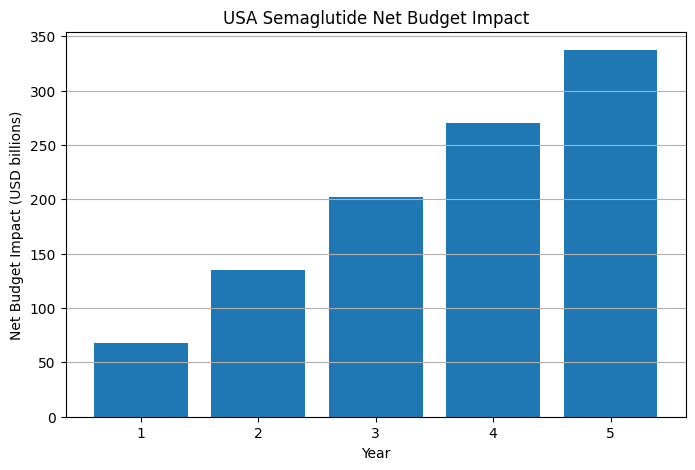

In [31]:
plt.figure(figsize=(8,5))


plt.bar(
    usa_budget["Year"],
    usa_budget["Net Budget Impact"]/1_000_000_000
)


plt.title(
    "USA Semaglutide Net Budget Impact"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Net Budget Impact (USD billions)"
)


plt.grid(axis="y")


plt.savefig(
    usa_figures / "usa_net_budget_impact.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [32]:
list(usa_figures.glob("*"))

[WindowsPath('../reports/usa/figures/usa_budget_impact.png'),
 WindowsPath('../reports/usa/figures/usa_cost_vs_savings.png'),
 WindowsPath('../reports/usa/figures/usa_net_budget_impact.png'),
 WindowsPath('../reports/usa/figures/usa_treated_population.png'),
 WindowsPath('../reports/usa/figures/usa_treated_population_growth.png')]

In [33]:
import matplotlib.pyplot as plt
import numpy as np

In [34]:
usa_summary = {
    "Adult Population\n(million)": 269.8,
    "Obesity\nPrevalence (%)": 33.1,
    "Eligible Population\n(million)": 89.2,
    "Annual Treatment\nCost ($)": 17537,
    "Year 1 Budget\nImpact ($B)": 67.5,
    "Year 5 Budget\nImpact ($B)": 337.3
}


usa_summary

{'Adult Population\n(million)': 269.8,
 'Obesity\nPrevalence (%)': 33.1,
 'Eligible Population\n(million)': 89.2,
 'Annual Treatment\nCost ($)': 17537,
 'Year 1 Budget\nImpact ($B)': 67.5,
 'Year 5 Budget\nImpact ($B)': 337.3}

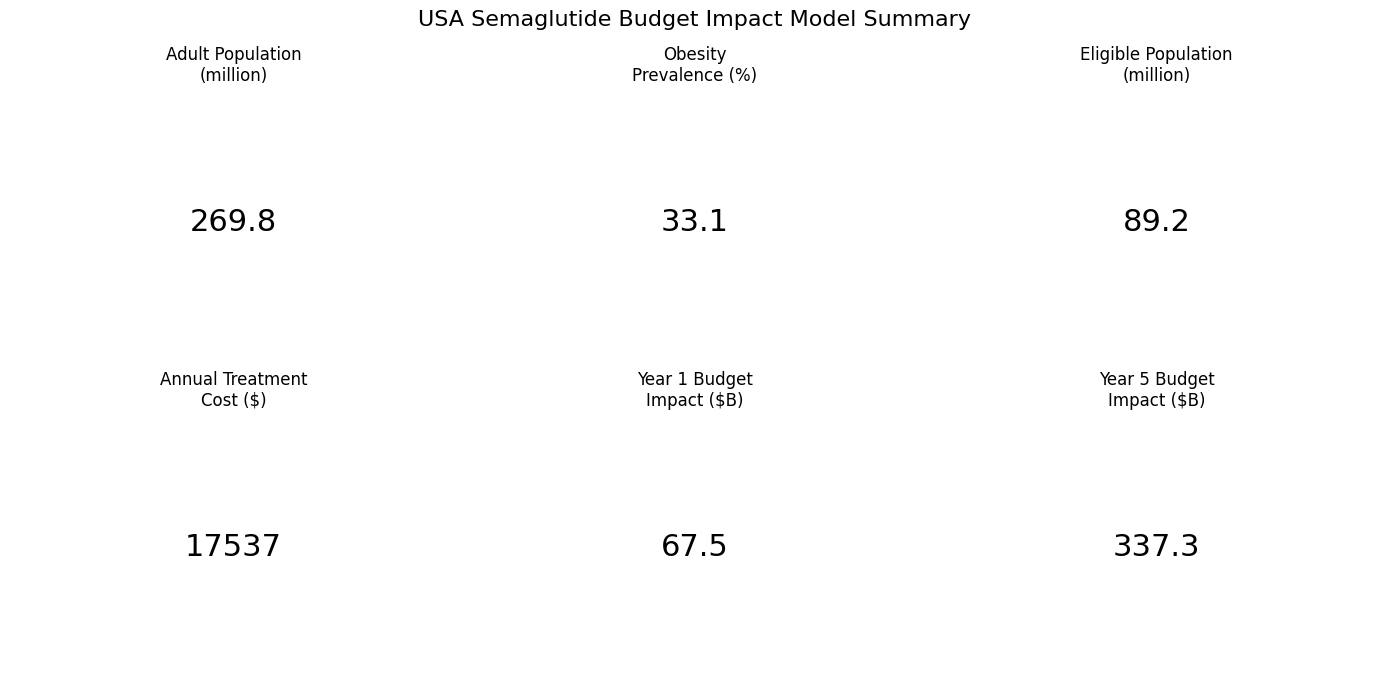

In [35]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14,7)
)


fig.suptitle(
    "USA Semaglutide Budget Impact Model Summary",
    fontsize=16
)


metrics = list(usa_summary.keys())
values = list(usa_summary.values())


for ax, metric, value in zip(
    axes.flatten(),
    metrics,
    values
):
    
    ax.text(
        0.5,
        0.5,
        str(value),
        fontsize=22,
        ha="center",
        va="center"
    )
    
    ax.set_title(metric)
    
    ax.axis("off")


plt.tight_layout()


plt.savefig(
    usa_figures / "usa_model_summary_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [36]:
list(usa_figures.glob("*"))

[WindowsPath('../reports/usa/figures/usa_budget_impact.png'),
 WindowsPath('../reports/usa/figures/usa_cost_vs_savings.png'),
 WindowsPath('../reports/usa/figures/usa_model_summary_dashboard.png'),
 WindowsPath('../reports/usa/figures/usa_net_budget_impact.png'),
 WindowsPath('../reports/usa/figures/usa_treated_population.png'),
 WindowsPath('../reports/usa/figures/usa_treated_population_growth.png')]